# Week 2 — Probability & Statistics for Forecasting

This notebook reviews the statistical foundations of forecasting: probability distributions, maximum likelihood estimation, and hypothesis testing — with emphasis on their role in time-series modelling.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# Edinburgh palette
UOE_RED   = '#7A2318'
UOE_GOLD  = '#B8860B'
UOE_BLUE  = '#2a78d6'
UOE_GREY  = '#52514e'
COLOURS   = [UOE_RED, UOE_BLUE, UOE_GOLD, '#2ca02c', '#9467bd', '#e377c2']

mpl.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.prop_cycle': mpl.cycler(color=COLOURS),
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 12, 'axes.titlesize': 14,
    'font.size': 11, 'legend.fontsize': 10,
    'lines.linewidth': 2,
})
print("Plotting style set ✓")


Plotting style set ✓


## 2.1 Key Distributions in Forecasting

Three distributions appear constantly:

- **Normal** — the workhorse; errors in most linear models
- **Student-$t$** — heavier tails; robust to outliers
- **Laplace** — even heavier tails; connection to $L_1$ estimation

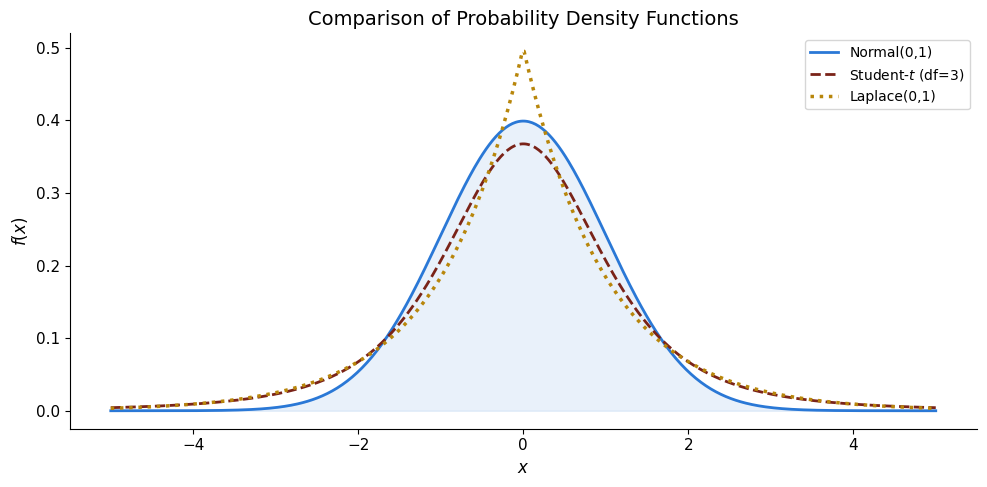

In [2]:
from scipy.stats import norm, t as student_t, laplace

x = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, norm.pdf(x), label='Normal(0,1)', color=UOE_BLUE)
ax.plot(x, student_t.pdf(x, df=3), '--', label='Student-$t$ (df=3)', color=UOE_RED)
ax.plot(x, laplace.pdf(x), ':', label='Laplace(0,1)', color=UOE_GOLD, lw=2.5)
ax.fill_between(x, norm.pdf(x), alpha=0.1, color=UOE_BLUE)
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Comparison of Probability Density Functions')
ax.legend()
plt.tight_layout()
plt.show()


## 2.2 Effect of Outliers on Distribution Fitting

When data contains outliers, the Normal distribution shifts its mean and inflates its variance to accommodate them. The Student-$t$ distribution is more robust.

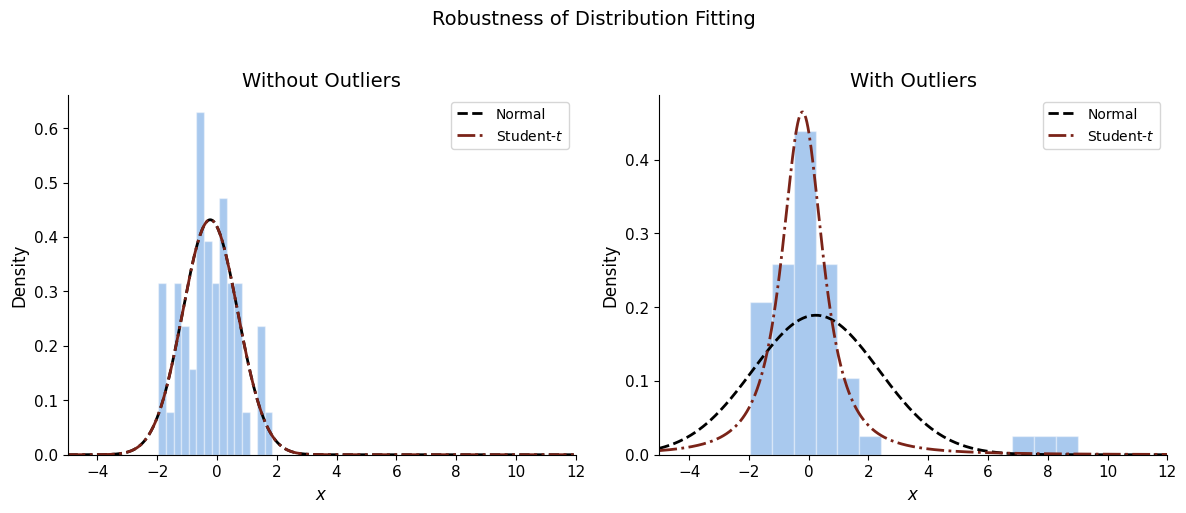

In [3]:
np.random.seed(42)
clean = np.random.normal(0, 1, 50)
outliers = np.array([7, 8, 9])
contaminated = np.concatenate([clean, outliers])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.linspace(-5, 12, 500)

for ax, data, title in [(ax1, clean, 'Without Outliers'),
                         (ax2, contaminated, 'With Outliers')]:
    ax.hist(data, bins=15, density=True, alpha=0.4, color=UOE_BLUE, edgecolor='white')

    mu, sigma = norm.fit(data)
    ax.plot(x, norm.pdf(x, mu, sigma), '--', color='k', lw=2, label='Normal')

    df, loc, scale = student_t.fit(data)
    ax.plot(x, student_t.pdf(x, df, loc, scale), '-.',
            color=UOE_RED, lw=2, label='Student-$t$')

    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.set_ylabel('Density')
    ax.legend()
    ax.set_xlim(-5, 12)

plt.suptitle('Robustness of Distribution Fitting', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 2.3 Maximum Likelihood Estimation

Given data $y_1, \dots, y_T$ and a model $f(y|\theta)$, the MLE solves:

$$\hat{\theta}_{\text{MLE}} = \arg\max_\theta \sum_{t=1}^{T} \log f(y_t | \theta)$$

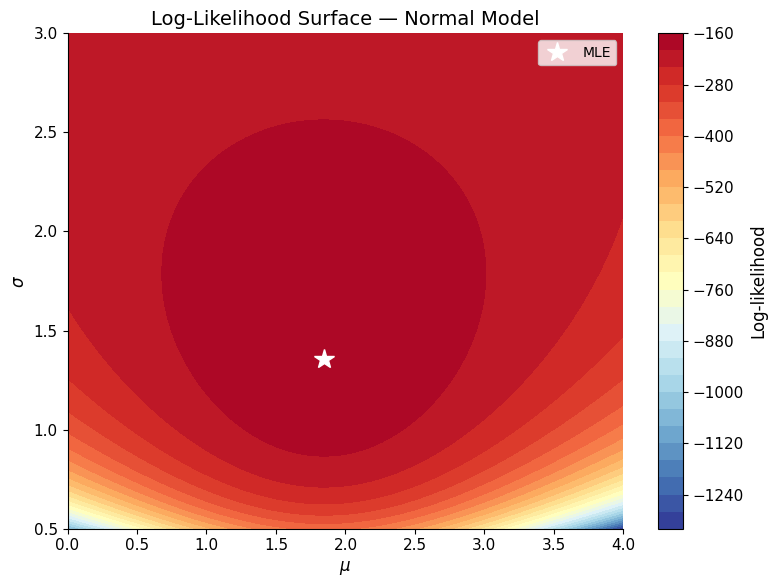

MLE: μ = 1.844, σ = 1.355


In [4]:
# MLE for Normal distribution: visualise the log-likelihood surface
np.random.seed(42)
data = np.random.normal(loc=2, scale=1.5, size=100)

mu_grid = np.linspace(0, 4, 100)
sigma_grid = np.linspace(0.5, 3, 100)
MU, SIGMA = np.meshgrid(mu_grid, sigma_grid)
LL = np.zeros_like(MU)

for i in range(len(sigma_grid)):
    for j in range(len(mu_grid)):
        LL[i, j] = np.sum(norm.logpdf(data, loc=MU[i, j], scale=SIGMA[i, j]))

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(MU, SIGMA, LL, levels=30, cmap='RdYlBu_r')
ax.plot(np.mean(data), np.std(data), 'w*', markersize=15, label='MLE')
ax.set_xlabel('$\\mu$')
ax.set_ylabel('$\\sigma$')
ax.set_title('Log-Likelihood Surface — Normal Model')
plt.colorbar(cs, label='Log-likelihood')
ax.legend()
plt.tight_layout()
plt.show()
print(f"MLE: μ = {np.mean(data):.3f}, σ = {np.std(data):.3f}")


## 2.4 OLS as MLE under Normality

For a linear model $y_t = x_t'\beta + \varepsilon_t$ with $\varepsilon_t \sim N(0, \sigma^2)$, maximising the log-likelihood is equivalent to minimising the sum of squared residuals.

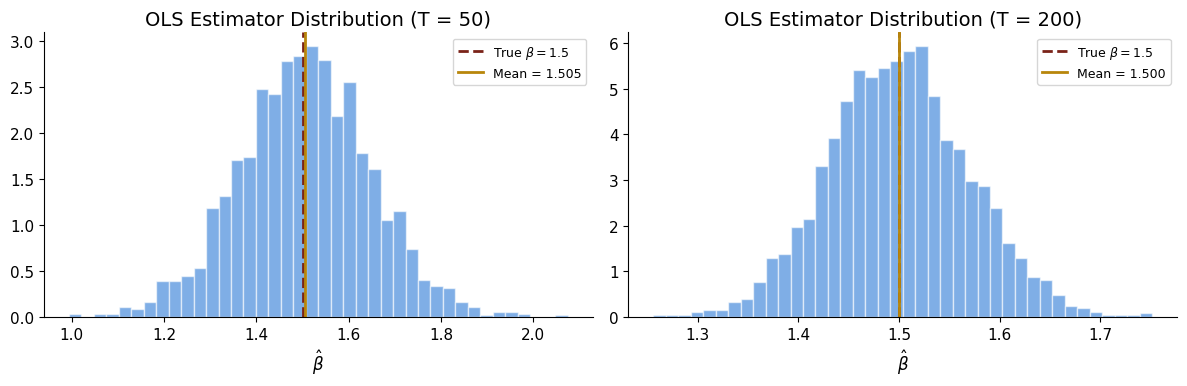

In [5]:
# Monte Carlo: OLS estimator distribution
np.random.seed(0)
N_sim = 2000
T_vals = [50, 200]
true_beta = 1.5

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, T in zip(axes, T_vals):
    betas = []
    for _ in range(N_sim):
        x = np.random.normal(0, 1, T)
        y = true_beta * x + np.random.normal(0, 1, T)
        beta_hat = np.sum(x * y) / np.sum(x**2)
        betas.append(beta_hat)
    ax.hist(betas, bins=40, density=True, alpha=0.6, color=UOE_BLUE, edgecolor='white')
    ax.axvline(true_beta, color=UOE_RED, lw=2, ls='--', label=f'True $\\beta = {true_beta}$')
    ax.axvline(np.mean(betas), color=UOE_GOLD, lw=2, label=f'Mean = {np.mean(betas):.3f}')
    ax.set_title(f'OLS Estimator Distribution (T = {T})')
    ax.set_xlabel('$\\hat{{\\beta}}$')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Exercises

<details><summary>Exercise 1: Fit Normal, Student-$t$, and Laplace to stock returns and compare AIC.</summary>

```python
from scipy.stats import norm, t, laplace
returns = np.random.standard_t(df=5, size=500)  # simulated fat-tailed returns
for dist, name in [(norm, 'Normal'), (t, 'Student-t'), (laplace, 'Laplace')]:
    params = dist.fit(returns)
    ll = np.sum(dist.logpdf(returns, *params))
    k = len(params)
    aic = 2*k - 2*ll
    print(f'{name}: AIC = {aic:.1f}')
```
</details>